# Clasificador de Cáncer de Piel con Deep Learning
## Curso de Formación Profesional — Inteligencia Artificial y Big Data

---

## ¿Qué vamos a hacer?

Entrenar una **red neuronal convolucional (CNN)** que analiza fotos de lunares y decide si el paciente debería consultar a un dermatólogo.

**Dataset:** HAM10000 — Skin Cancer MNIST  
> 10.015 imágenes dermatoscópicas de 7 tipos de lesiones cutáneas

**Problema:** Clasificación binaria
| Etiqueta | Significado | Clases originales |
|----------|-------------|-------------------|
| 0 — Benigno | No urgente | `nv`, `bkl`, `df`, `vasc` |
| 1 — Revisar | Consultar dermatólogo | `mel`, `bcc`, `akiec` |

**Técnica principal:** Transfer Learning con MobileNetV2 (preentrenada en ImageNet)

---

## Estructura del notebook
1. Configuración e imports
2. Carga y exploración del dataset (EDA)
3. Preparación de datos e Image Augmentation
4. Construcción del modelo (Transfer Learning)
5. Entrenamiento
6. Evaluación y métricas
7. Inferencia en imagen nueva
8. Guardado del modelo

## 0. Descarga del Dataset

### Opción A — Con Kaggle API (recomendado)
```bash
# Dentro del contenedor o en terminal:
kaggle datasets download -d kmader/skin-lesion-analysis-toward-melanoma-detection \
    -p /workspace/data --unzip
```

> Para usar Kaggle API necesitas `~/.kaggle/kaggle.json` con tus credenciales.  
> Descárgalo en: https://www.kaggle.com/settings → API → Create New Token

### Opción B — Manual
1. Ve a https://www.kaggle.com/datasets/kmader/skin-lesion-analysis-toward-melanoma-detection
2. Descarga y descomprime en la carpeta `data/`

### Estructura esperada en `data/`:
```
data/
├── HAM10000_metadata.csv
├── HAM10000_images_part_1/   (5.000 imágenes .jpg)
└── HAM10000_images_part_2/   (5.015 imágenes .jpg)
```

---
## 1. Configuración e Imports

In [3]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ── Datos y visualización ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# ── Semilla de aleatoriedad (reproducibilidad) ──────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow versión: {tf.__version__}')

keras_version = getattr(keras, '__version__', None)
if keras_version is None:
    try:
        import keras as standalone_keras
        keras_version = getattr(standalone_keras, '__version__', 'desconocida')
    except Exception:
        keras_version = 'desconocida'

print(f'Keras versión:      {keras_version}')
print(f'GPU disponible:     {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow versión: 2.15.0
Keras versión:      2.15.0
GPU disponible:     False


In [4]:
# ══════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN — Modifica estos valores si necesitas
# ══════════════════════════════════════════════════════════════════

DATA_DIR   = '/workspace/data'      # Ruta al dataset
MODEL_DIR  = '/workspace/notebooks' # Dónde guardar el modelo

IMG_SIZE   = (224, 224)  # MobileNetV2 espera 224x224
BATCH_SIZE = 32
EPOCHS     = 30          # EarlyStopping cortará antes si no mejora
LEARNING_RATE = 1e-4

# Clases que necesitan revisión dermatológica
MALIGNANT_CLASSES = {'mel', 'bcc', 'akiec'}

# Descripción de cada clase del dataset
CLASS_NAMES = {
    'nv':    'Nevo melanocítico (lunar común)',
    'mel':   'Melanoma',
    'bkl':   'Queratosis benigna',
    'bcc':   'Carcinoma basocelular',
    'akiec': 'Queratosis actínica / Carcinoma espinocelular',
    'vasc':  'Lesión vascular',
    'df':    'Dermatofibroma'
}

---
## 2. Carga y Exploración del Dataset (EDA)

> **EDA** = Exploratory Data Analysis. Antes de entrenar cualquier modelo,  
> siempre hay que entender los datos: cuántos hay, si están balanceados, qué aspecto tienen.

In [12]:
# ── Cargar metadata ──────────────────────────────────────────────────────────
import glob

# Intentar localizar el CSV en DATA_DIR o en subcarpetas
candidate_paths = [
    os.path.join(DATA_DIR, 'HAM10000_metadata.csv'),
    *glob.glob(os.path.join(DATA_DIR, '**', 'HAM10000_metadata.csv'), recursive=True),
]

# Eliminar duplicados conservando orden
seen = set()
candidate_paths = [p for p in candidate_paths if not (p in seen or seen.add(p))]
meta_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if meta_path is None:
    existing = sorted(glob.glob(os.path.join(DATA_DIR, '*')))
    print(f'No se encontró HAM10000_metadata.csv en: {DATA_DIR}')
    print('Contenido actual de data/:')
    if existing:
        for p in existing[:20]:
            print(f'  - {p}')
    else:
        print('  (vacío)')
    raise FileNotFoundError(
        'Dataset no encontrado. Descárgalo en la sección 0 del notebook o ejecuta download_dataset.sh.'
    )

df = pd.read_csv(meta_path)

print(f'Metadata cargada desde: {meta_path}')
print(f'Total imágenes: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
df.head()

Metadata cargada desde: /workspace/data/HAM10000_metadata.csv
Total imágenes: 10,015
Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [13]:
# ── Función para localizar cada imagen (están en 2 carpetas) ─────────────────
def find_image(image_id: str) -> str | None:
    """Busca la imagen en part_1 y part_2, devuelve la ruta o None."""
    for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        path = os.path.join(DATA_DIR, part, f'{image_id}.jpg')
        if os.path.exists(path):
            return path
    return None

df['filepath'] = df['image_id'].apply(find_image)

missing = df['filepath'].isna().sum()
print(f'Imágenes encontradas: {len(df) - missing:,} / {len(df):,}')
if missing > 0:
    print(f'⚠️  {missing} imágenes no encontradas — verifica la carpeta data/')
    df = df.dropna(subset=['filepath'])

Imágenes encontradas: 10,015 / 10,015


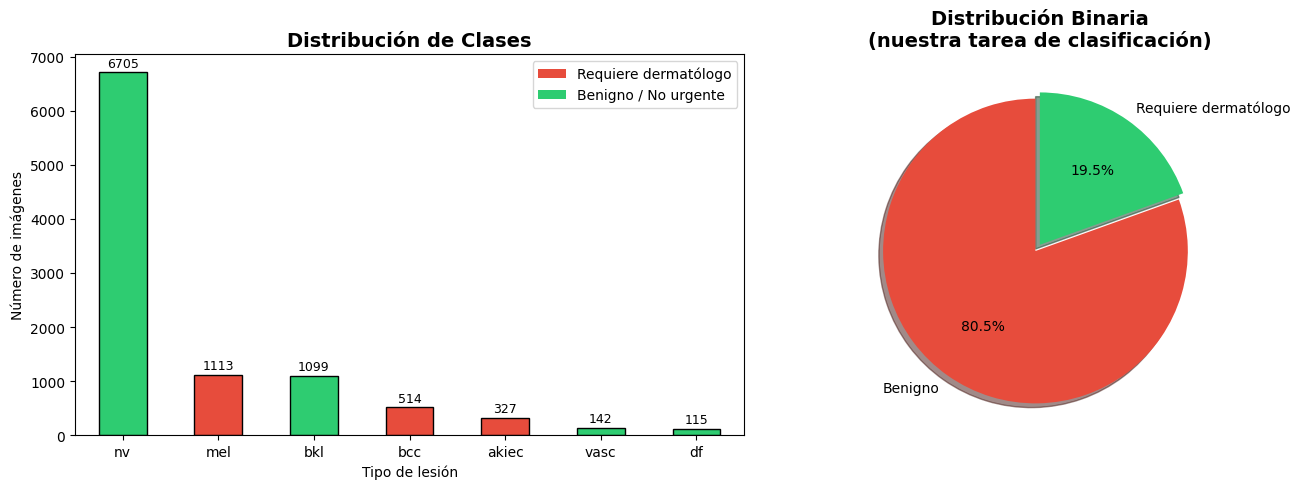


⚠️  DESBALANCEO DE CLASES:
El dataset no está balanceado — más lunares benignos que malignos.
Lo corregiremos con class_weights en el entrenamiento.


In [14]:
# ── Distribución de clases ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['dx'].value_counts()

# Barras
colors = ['#e74c3c' if c in MALIGNANT_CLASSES else '#2ecc71'
          for c in class_counts.index]
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de lesión')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=0)
for bar, count in zip(axes[0].patches, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontsize=9)

# Leyenda de colores
from matplotlib.patches import Patch
legend = [Patch(facecolor='#e74c3c', label='Requiere dermatólogo'),
          Patch(facecolor='#2ecc71', label='Benigno / No urgente')]
axes[0].legend(handles=legend)

# Pie chart
df['binary_label_text'] = df['dx'].apply(
    lambda x: 'Requiere dermatólogo' if x in MALIGNANT_CLASSES else 'Benigno'
)
binary_counts = df['binary_label_text'].value_counts()
axes[1].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            explode=(0.05, 0), shadow=True)
axes[1].set_title('Distribución Binaria\n(nuestra tarea de clasificación)',
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  DESBALANCEO DE CLASES:')
print('El dataset no está balanceado — más lunares benignos que malignos.')
print('Lo corregiremos con class_weights en el entrenamiento.')

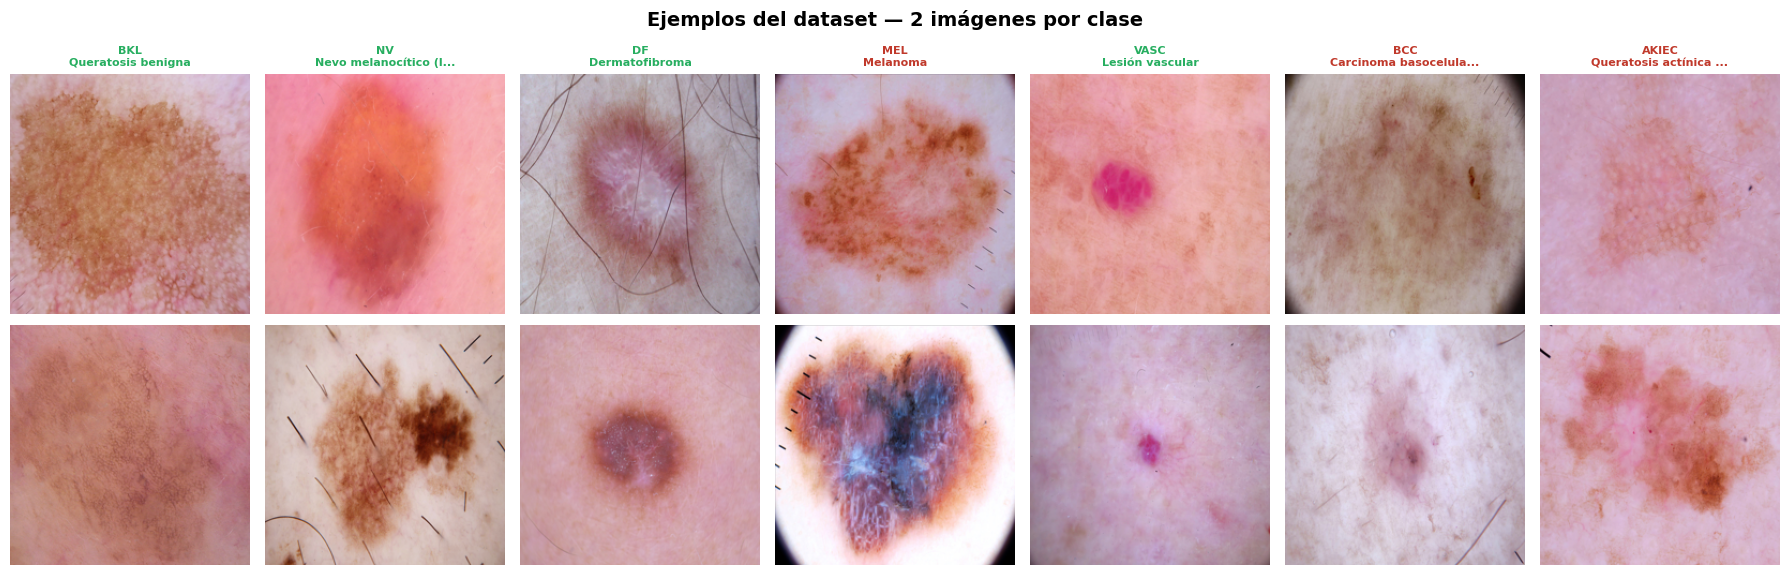

In [15]:
# ── Mostrar imágenes de ejemplo de cada clase ────────────────────────────────
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle('Ejemplos del dataset — 2 imágenes por clase', fontsize=14, fontweight='bold')

for col, dx in enumerate(df['dx'].unique()):
    samples = df[df['dx'] == dx].sample(2, random_state=SEED)
    for row, (_, sample) in enumerate(samples.iterrows()):
        img = Image.open(sample['filepath']).resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            color = '#c0392b' if dx in MALIGNANT_CLASSES else '#27ae60'
            axes[row, col].set_title(
                f'{dx.upper()}\n{CLASS_NAMES[dx][:20]}...' if len(CLASS_NAMES[dx]) > 20
                else f'{dx.upper()}\n{CLASS_NAMES[dx]}',
                color=color, fontsize=8, fontweight='bold'
            )

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Estadísticas básicas ─────────────────────────────────────────────────────
print('=== Información del Dataset ===')
print(f"\nTotal imágenes:          {len(df):,}")
print(f"Rango de edad pacientes: {df['age'].min():.0f} - {df['age'].max():.0f} años")
print(f"Sexo (%):\n{df['sex'].value_counts(normalize=True).mul(100).round(1).to_string()}")
print(f"\nLocalización más frecuente:\n{df['localization'].value_counts().head().to_string()}")

=== Información del Dataset ===

Total imágenes:          10,015
Rango de edad pacientes: 0 - 85 años
Sexo (%):
sex
male       54.0
female     45.5
unknown     0.6

Localización más frecuente:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022


---
## 3. Preparación de Datos

### Pasos:
1. **Crear etiqueta binaria** — 0 benigno, 1 necesita revisión
2. **Dividir** en train / validation / test
3. **Image Augmentation** — multiplicar variedad de imágenes artificialmente
4. **Normalización** — píxeles de [0,255] a [0,1]

### ¿Por qué Image Augmentation?
Con 10.000 imágenes, la red puede memorizar en vez de aprender.  
Rotaciones, flips y zoom artificiales crean nuevas variaciones y mejoran generalización.

In [17]:
# ── Crear etiqueta binaria ───────────────────────────────────────────────────
df['label'] = df['dx'].apply(lambda x: 1 if x in MALIGNANT_CLASSES else 0)
df['label_text'] = df['label'].map({0: 'benigno', 1: 'revisar'})

print('Distribución binaria:')
print(df['label'].value_counts().to_string())
print(f"\nRatio desbalanceo: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.1f}x más benignos")

Distribución binaria:
label
0    8061
1    1954

Ratio desbalanceo: 4.1x más benignos


In [18]:
# ── División Train / Validation / Test ───────────────────────────────────────
# 70% train — 15% validation — 15% test
# stratify=label para mantener proporción de clases en cada split

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f'Train:      {len(train_df):,} imágenes ({len(train_df)/len(df)*100:.0f}%)')
print(f'Validación: {len(val_df):,} imágenes ({len(val_df)/len(df)*100:.0f}%)')
print(f'Test:       {len(test_df):,} imágenes ({len(test_df)/len(df)*100:.0f}%)')

Train:      7,010 imágenes (70%)
Validación: 1,502 imágenes (15%)
Test:       1,503 imágenes (15%)


In [19]:
# ── Class Weights (compensar desbalanceo) ────────────────────────────────────
# Si hay 7x más benignos, damos 7x más importancia al error en malignos

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)
class_weights = {0: weights[0], 1: weights[1]}
print(f'Class weights: benigno={class_weights[0]:.3f} | revisar={class_weights[1]:.3f}')
print('→ El modelo penalizará más los errores en clase "revisar"')

Class weights: benigno=0.621 | revisar=2.562
→ El modelo penalizará más los errores en clase "revisar"


In [20]:
# ── ImageDataGenerator — Augmentation para train, solo normalización para val/test ──

# MobileNetV2 espera píxeles en [-1, 1] — usamos su propio preprocessor
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,          # Rotar hasta ±20°
    width_shift_range=0.1,      # Desplazar horizontalmente
    height_shift_range=0.1,     # Desplazar verticalmente
    shear_range=0.1,            # Deformación
    zoom_range=0.1,             # Zoom in/out
    horizontal_flip=True,       # Espejo horizontal
    vertical_flip=True,         # Espejo vertical (lunares, aplica)
    fill_mode='nearest'         # Rellenar pixels nuevos con el vecino más próximo
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # Solo normalizar, sin augmentation
)

# ── Crear generadores ─────────────────────────────────────────────────────────
def make_generator(datagen, dataframe, shuffle=False):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='filepath',
        y_col='label_text',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=['benigno', 'revisar'],  # 0=benigno, 1=revisar
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
val_gen   = make_generator(val_test_datagen, val_df,   shuffle=False)
test_gen  = make_generator(val_test_datagen, test_df,  shuffle=False)

print(f'Clase 0 (benigno): {train_gen.class_indices}')

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Clase 0 (benigno): {'benigno': 0, 'revisar': 1}


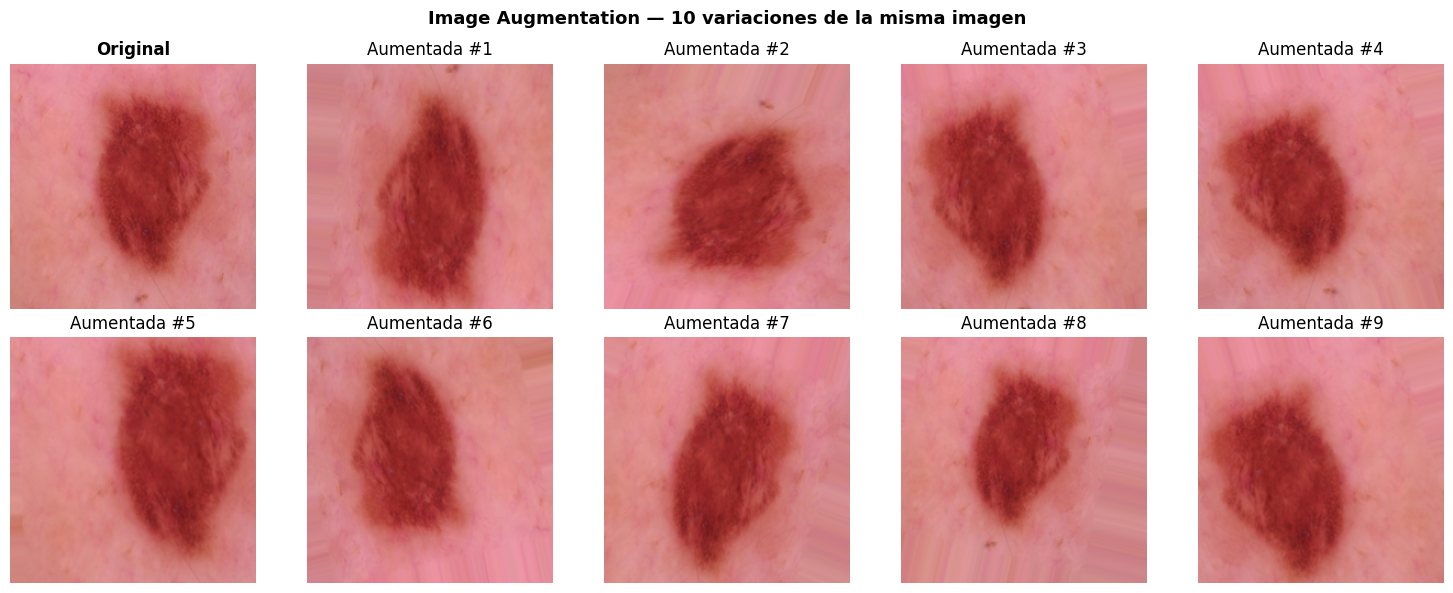

In [21]:
# ── Visualizar augmentation ───────────────────────────────────────────────────
sample_img = Image.open(train_df.iloc[0]['filepath']).resize(IMG_SIZE)
sample_arr = np.expand_dims(np.array(sample_img), 0)  # (1, 224, 224, 3)

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.2, horizontal_flip=True, vertical_flip=True
).flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Image Augmentation — 10 variaciones de la misma imagen',
             fontsize=13, fontweight='bold')
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    aug = next(aug_gen)[0].astype(np.uint8)
    ax.imshow(aug)
    ax.set_title(f'Aumentada #{i+1}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'augmentation_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Construcción del Modelo — Transfer Learning

### ¿Qué es Transfer Learning?

En vez de entrenar una red desde cero (necesitaríamos millones de imágenes y semanas de GPU),  
usamos **MobileNetV2** — ya entrenada con **1,2 millones de imágenes** de ImageNet.

Estrategia en 2 fases:
```
FASE 1 — Feature Extraction (capas congeladas)
  MobileNetV2 (frozen) → Nuevo clasificador
  Solo aprende la cabeza nueva. Rápido y estable.

FASE 2 — Fine-tuning (descongelar últimas capas)
  Últimas capas MobileNetV2 + Nuevo clasificador
  Ajuste fino con LR muy bajo. Mejora rendimiento.
```

### Arquitectura
```
Input (224, 224, 3)
    ↓
MobileNetV2 (backbone) ← pesos ImageNet, congelados en Fase 1
    ↓
GlobalAveragePooling2D  ← reduce (7,7,1280) → (1280,)
    ↓
Dense(256, relu) + Dropout(0.4)
    ↓
Dense(64, relu) + Dropout(0.2)
    ↓
Dense(1, sigmoid)       ← probabilidad [0,1]
```

In [22]:
def build_model(input_shape=(224, 224, 3), learning_rate=LEARNING_RATE):
    """Construye modelo con MobileNetV2 como backbone."""

    # ── Backbone — MobileNetV2 preentrenada ──────────────────────────────────
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,      # Sin la capa final de ImageNet (1000 clases)
        weights='imagenet'      # Pesos preentrenados
    )
    base_model.trainable = False  # Congelar para Fase 1

    # ── Cabeza clasificadora nueva ───────────────────────────────────────────
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)       # training=False → BatchNorm congelado
    x = layers.GlobalAveragePooling2D()(x)       # (7,7,1280) → (1280,)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)                   # Regularización — evitar overfitting
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # Probabilidad clase positiva

    model = Model(inputs, outputs, name='skin_cancer_classifier')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Recall(name='recall'),       # Sensibilidad — importante en medicina
            keras.metrics.Precision(name='precision')
        ]
    )

    return model, base_model


model, base_model = build_model()

print(f'Parámetros totales:    {model.count_params():,}')
print(f'Parámetros entrenables: {sum(p.numpy().size for p in model.trainable_variables):,}')
print(f'Parámetros congelados:  {sum(p.numpy().size for p in model.non_trainable_variables):,}')

9406464/9406464 [==============================] - 0s 0us/step
Parámetros totales:    2,602,433
Parámetros entrenables: 344,449
Parámetros congelados:  2,257,984


In [23]:
# Resumen de la arquitectura
model.summary(line_length=80)

Model: "skin_cancer_classifier"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 input_2 (InputLayer)               [(None, 224, 224, 3)]           0           
                                                                                
 mobilenetv2_1.00_224 (Functional)  (None, 7, 7, 1280)              2257984     
                                                                                
 global_average_pooling2d (GlobalA  (None, 1280)                    0           
 veragePooling2D)                                                               
                                                                                
 dense (Dense)                      (None, 256)                     327936      
                                                                                
 dropout (Dropout)                  (None, 256)                     0        

---
## 5. Entrenamiento

### Callbacks — comportamiento automático durante el entrenamiento

| Callback | Función |
|---|---|
| `EarlyStopping` | Para si val_loss no mejora N epochs (evita overfitting) |
| `ModelCheckpoint` | Guarda el mejor modelo automáticamente |
| `ReduceLROnPlateau` | Reduce LR si el modelo se estanca |

In [24]:
best_model_path = os.path.join(MODEL_DIR, 'best_model_phase1.keras')

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,       # LR × 0.3 cuando se estanca
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [25]:
# ════════════════════════════════════════════════════════════════
# FASE 1 — Feature Extraction (solo la cabeza nueva aprende)
# ════════════════════════════════════════════════════════════════
print('FASE 1: Entrenando solo la cabeza clasificadora...')
print('Backbone MobileNetV2: CONGELADO')
print('='*50)

history_phase1 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

FASE 1: Entrenando solo la cabeza clasificadora...
Backbone MobileNetV2: CONGELADO
Epoch 1/30
220/220 [==============================] - ETA: 0s - loss: 0.5908 - accuracy: 0.6894 - auc: 0.7557 - recall: 0.6908 - precision: 0.3501
Epoch 1: val_auc improved from -inf to 0.83639, saving model to /workspace/notebooks/best_model_phase1.keras
220/220 [==============================] - 136s 614ms/step - loss: 0.5908 - accuracy: 0.6894 - auc: 0.7557 - recall: 0.6908 - precision: 0.3501 - val_loss: 0.5167 - val_accuracy: 0.7410 - val_auc: 0.8364 - val_recall: 0.7952 - val_precision: 0.4146 - lr: 1.0000e-04
Epoch 2/30
116/220 [==============>...............] - ETA: 38s - loss: 0.5084 - accuracy: 0.7338 - auc: 0.8311 - recall: 0.7829 - precision: 0.4130

KeyboardInterrupt: 

In [ ]:
# ════════════════════════════════════════════════════════════════
# FASE 2 — Fine-tuning (descongelar últimas capas del backbone)
# ════════════════════════════════════════════════════════════════
print(f'Total capas en MobileNetV2: {len(base_model.layers)}')

# Descongelar el 30% final del backbone
FINE_TUNE_AT = int(len(base_model.layers) * 0.70)
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompilar con LR mucho más bajo (no queremos destruir los pesos aprendidos)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

print(f'Capas congeladas:     {FINE_TUNE_AT}')
print(f'Capas entrenables:    {len(base_model.layers) - FINE_TUNE_AT} (backbone) + cabeza')
print(f'Learning Rate:        {LEARNING_RATE / 10} (10x más bajo que Fase 1)')
print('='*50)

best_model_path2 = os.path.join(MODEL_DIR, 'best_model_phase2.keras')
callbacks[1] = ModelCheckpoint(
    filepath=best_model_path2, monitor='val_auc',
    save_best_only=True, mode='max', verbose=1
)

print('FASE 2: Fine-tuning...')
history_phase2 = model.fit(
    train_gen,
    epochs=EPOCHS // 2,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

In [ ]:
# ── Graficar historial de entrenamiento ──────────────────────────────────────
def plot_history(h1, h2=None):
    metrics = ['loss', 'accuracy', 'auc', 'recall']
    titles  = ['Pérdida (Loss)', 'Exactitud (Accuracy)', 'AUC-ROC', 'Recall (Sensibilidad)']

    # Concatenar fases
    def concat(key):
        v1 = h1.history.get(key, [])
        v2 = h2.history.get(key, []) if h2 else []
        return v1 + v2

    phase1_end = len(h1.history['loss'])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Historial de Entrenamiento', fontsize=16, fontweight='bold')

    for ax, metric, title in zip(axes.flat, metrics, titles):
        train_vals = concat(metric)
        val_vals   = concat(f'val_{metric}')
        epochs_r   = range(1, len(train_vals) + 1)

        ax.plot(epochs_r, train_vals, 'b-o', markersize=3, label='Train')
        ax.plot(epochs_r, val_vals,   'r-o', markersize=3, label='Validación')

        if h2 and phase1_end < len(train_vals):
            ax.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7,
                       label='Inicio Fine-tuning')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Época')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_phase1, history_phase2)

---
## 6. Evaluación

### Métricas importantes en aplicaciones médicas

| Métrica | Fórmula | ¿Por qué importa? |
|---|---|---|
| **Recall / Sensibilidad** | TP / (TP + FN) | Detectar todos los malignos — falso negativo = peligroso |
| **Precisión** | TP / (TP + FP) | Evitar alarmas falsas — afecta calidad de vida |
| **AUC-ROC** | Área bajo curva ROC | Rendimiento global independiente del umbral |
| **F1-Score** | 2×(P×R)/(P+R) | Balance entre precisión y recall |

> En medicina, el **Recall** suele primar sobre la Precisión:  
> mejor una alarma falsa extra que perder un melanoma.

In [ ]:
# ── Cargar mejor modelo y evaluar en test ────────────────────────────────────
best_model = keras.models.load_model(best_model_path2)

print('Evaluación en conjunto de TEST (datos nunca vistos):')
results = best_model.evaluate(test_gen, verbose=1)
metric_names = best_model.metrics_names

print('\n' + '='*40)
for name, val in zip(metric_names, results):
    print(f'  {name:12s}: {val:.4f}')

In [ ]:
# ── Predicciones para métricas detalladas ────────────────────────────────────
test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1)  # Probabilidades [0,1]
y_pred = (y_prob > 0.5).astype(int).flatten()    # Umbral 0.5 → etiqueta binaria
y_true = test_gen.classes                         # Etiquetas reales

print('\nReporte de Clasificación:')
print(classification_report(
    y_true, y_pred,
    target_names=['Benigno (0)', 'Revisar (1)']
))

print(f'AUC-ROC: {roc_auc_score(y_true, y_prob):.4f}')

In [ ]:
# ── Matriz de Confusión + Curva ROC ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Matriz de Confusión —
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benigno', 'Revisar'],
            yticklabels=['Benigno', 'Revisar'])
axes[0].set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Predicción del Modelo')

# Anotar cuadrantes
labels = [['✓ Verdadero\nNegativo', '✗ Falso\nPositivo'],
          ['✗ Falso\nNegativo', '✓ Verdadero\nPositivo']]
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.75, labels[i][j],
                     ha='center', va='center', fontsize=8,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# — Curva ROC —
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Modelo (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Clasificador aleatorio (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1)
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
axes[1].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'evaluation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas de la matriz
tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Negativos (benigno predicho benigno): {tn}')
print(f'Falsos Positivos     (benigno predicho revisar): {fp}  ← alarma falsa')
print(f'Falsos Negativos     (revisar predicho benigno): {fn}  ← PELIGROSO')
print(f'Verdaderos Positivos (revisar predicho revisar): {tp}')

In [ ]:
# ── Ajuste de umbral — optimizar para minimizar Falsos Negativos ─────────────
print('Análisis de Recall según umbral de decisión:')
print('(Umbral más bajo → más sensible → menos falsos negativos)')
print()
print(f'{"Umbral":>8} | {"Recall":>8} | {"Precisión":>10} | {"F1":>8} | {"Falsos Neg":>12}')
print('-' * 60)

from sklearn.metrics import f1_score, precision_score, recall_score
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (y_prob > thresh).astype(int).flatten()
    rec = recall_score(y_true, pred_t, zero_division=0)
    pre = precision_score(y_true, pred_t, zero_division=0)
    f1  = f1_score(y_true, pred_t, zero_division=0)
    fn_t = confusion_matrix(y_true, pred_t).ravel()[2]
    marker = ' ← recomendado' if thresh == 0.4 else ''
    print(f'{thresh:>8.1f} | {rec:>8.3f} | {pre:>10.3f} | {f1:>8.3f} | {fn_t:>12}{marker}')

---
## 7. Inferencia — Predicción en Imagen Nueva

Simulamos el caso de uso real: el médico/paciente sube una foto y el modelo da su veredicto.

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

DECISION_THRESHOLD = 0.4  # Umbral conservador para uso médico

def predict_mole(image_path: str, model, threshold: float = DECISION_THRESHOLD) -> dict:
    """
    Analiza una imagen de lunar y devuelve el veredicto.

    Args:
        image_path: Ruta a la imagen (.jpg/.png)
        model:      Modelo Keras entrenado
        threshold:  Umbral de decisión (default 0.4 para mayor sensibilidad)

    Returns:
        dict con probabilidad, etiqueta y recomendación
    """
    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.expand_dims(np.array(img), axis=0)  # (1, 224, 224, 3)
    img_array = mobilenet_preprocess(img_array.astype('float32'))

    prob = float(model.predict(img_array, verbose=0)[0][0])
    label = 1 if prob >= threshold else 0

    return {
        'probabilidad_maligno': prob,
        'probabilidad_benigno': 1 - prob,
        'etiqueta': label,
        'veredicto': 'CONSULTAR DERMATÓLOGO' if label == 1 else 'Sin urgencia aparente',
        'confianza': max(prob, 1-prob),
        'umbral_usado': threshold
    }


def show_prediction(image_path: str, model, true_label: int = None):
    """Muestra la imagen y el veredicto del modelo."""
    result = predict_mole(image_path, model)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Imagen
    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('Imagen analizada', fontweight='bold')

    # Barra de probabilidad
    probs = [result['probabilidad_benigno'], result['probabilidad_maligno']]
    bars = axes[1].barh(['Benigno', 'Revisar'], probs,
                        color=['#2ecc71', '#e74c3c'])
    axes[1].set_xlim(0, 1)
    axes[1].axvline(x=DECISION_THRESHOLD, color='black', linestyle='--',
                    alpha=0.5, label=f'Umbral: {DECISION_THRESHOLD}')
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{prob:.1%}', va='center', fontweight='bold')

    color = '#c0392b' if result['etiqueta'] == 1 else '#27ae60'
    title = f"\n{'⚠️  ' if result['etiqueta'] == 1 else '✓  '}{result['veredicto']}"
    if true_label is not None:
        correct = '✓ Correcto' if result['etiqueta'] == true_label else '✗ Incorrecto'
        title += f'\n[Etiqueta real: {"revisar" if true_label else "benigno"} — {correct}]'

    axes[1].set_title(title, color=color, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Probabilidad')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()
    return result


print('Función predict_mole() lista.')

In [ ]:
# ── Probar con imágenes del conjunto de test ─────────────────────────────────
# Un ejemplo benigno y uno maligno

print('=== Ejemplo 1: Imagen BENIGNA ===')
sample_benign = test_df[test_df['label'] == 0].iloc[0]
result1 = show_prediction(sample_benign['filepath'], best_model, true_label=0)
print(f"Clase real: {sample_benign['dx']} — {CLASS_NAMES[sample_benign['dx']]}")

print('\n=== Ejemplo 2: Imagen MALIGNA ===')
sample_malign = test_df[test_df['label'] == 1].iloc[0]
result2 = show_prediction(sample_malign['filepath'], best_model, true_label=1)
print(f"Clase real: {sample_malign['dx']} — {CLASS_NAMES[sample_malign['dx']]}")

In [ ]:
# ── Predecir TU PROPIA imagen ────────────────────────────────────────────────
# Sube una imagen a la carpeta /workspace/data/ y cambia la ruta

# MI_IMAGEN = '/workspace/data/mi_lunar.jpg'
# resultado = show_prediction(MI_IMAGEN, best_model)
# print(resultado)

print('Descomenta las líneas de arriba y pon la ruta a tu imagen.')

---
## 8. Guardar el Modelo

In [ ]:
# ── Guardar en formato Keras nativo ─────────────────────────────────────────
final_path = os.path.join(MODEL_DIR, 'skin_cancer_classifier_final.keras')
best_model.save(final_path)
print(f'Modelo guardado en: {final_path}')

# ── Guardar también en formato TensorFlow SavedModel (para producción) ────────
savedmodel_path = os.path.join(MODEL_DIR, 'skin_cancer_savedmodel')
best_model.export(savedmodel_path)
print(f'SavedModel guardado en: {savedmodel_path}')

In [ ]:
# ── Cómo cargar el modelo en el futuro ──────────────────────────────────────
print('Para cargar el modelo en otro script:')
print("""
import tensorflow as tf

# Opción 1 — Formato Keras
model = tf.keras.models.load_model('skin_cancer_classifier_final.keras')

# Opción 2 — SavedModel (para servir con TF Serving)
model = tf.saved_model.load('skin_cancer_savedmodel')
""")

---
## Resumen Final

### ¿Qué hemos construido?

Un clasificador binario que:
1. Recibe una foto de un lunar (224×224 píxeles)
2. Pasa por MobileNetV2 preentrenada (extrae features)
3. Devuelve la probabilidad de que sea maligno
4. Recomienda consulta si probabilidad ≥ 0.4

### Técnicas aplicadas
| Técnica | Problema que resuelve |
|---|---|
| Transfer Learning | Pocos datos de entrenamiento |
| Fine-tuning | Adaptar features a nuestro dominio |
| Image Augmentation | Overfitting, variedad |
| Class Weights | Desbalanceo de clases |
| EarlyStopping | Overfitting |
| Umbral ajustado (0.4) | Priorizar sensibilidad médica |

### Limitaciones importantes
- Este modelo es **educativo** — no usar para diagnóstico real sin validación clínica
- Dataset con cierto sesgo (mayoría lunares benignos)
- Imágenes dermatoscópicas requieren equipamiento especial — fotos de móvil pueden diferir

### Próximos pasos
- Clasificación multiclase (7 tipos)
- Grad-CAM para visualizar qué zonas activan la predicción
- Despliegue con FastAPI + Docker
- Validación con dataset externo